# Branched Signature Kernel Model for single trajectory rough linear ODEs

## Problem Introduction

The Problem is:

$$
\begin{align*}
&k_1 u''(x)+k_2 u'(x)+k u(x)=f(x)\\
&u(0)=a\\
&u'(0)=b
\end{align*}
$$
with constants $k_1,k_2,k_2,a,$ and $b$.

The forcing in this case is a fractional Brownian Motion


## Imports

In [1]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy fbm pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode import *
print("Using device:", device, "torch", torch.__version__)

# Cell 3 - seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Already up to date.
Using device: cuda torch 2.11.0+cu128


## Plotting Functions

## Problem Setup

In [2]:
# === Problem setup ===
# Interval and boundary conditions
a = 0.0       # start of x interval
b = 1      # end of x interval
ya = 0.0      # u(0)
ypa = 1.0     # u'(0)

# Operator coefficients
k1 = 1.0 #mass coeficient
k2 = 10      #dampening
k3 = 5      #stiffness

# Grid and forcing
N = 1000
x = torch.linspace(a, b, N, device=device)
hurst = .3  #Forcing Hurst Parameter

TRAIN_FRAC = 0.7  # fraction of grid points used for training



#Train / Test Split
N_train = int(N * TRAIN_FRAC)
N_test  = N - N_train

# Training slice: first N_train points (contiguous, causal split)
x_train = x[:N_train]
x_test  = x[N_train:]

print(f"Total grid points : {N}")
print(f"Train points      : {N_train}  (x in [{float(x_train[0]):.3f}, {float(x_train[-1]):.3f}])")
print(f"Test  points      : {N_test}   (x in [{float(x_test[0]):.3f},  {float(x_test[-1]):.3f}])")


Total grid points : 1000
Train points      : 700  (x in [0.000, 0.700])
Test  points      : 300   (x in [0.701,  1.000])


## Parameter Choices, and model hyperparameters

In [3]:
# Signature parameters
SIG_DEPTH      = 3         #Signature Depth

# Signature Normalization parameters
NORM_SCHEME = "col_robust"   # "none" or "col_zscore", "row_zscore" "row_robust", "col_robust", "row_unit", etc...
NORM_KWARGS = {}             #


#Kernel Parameters
KERNEL_TYPE = "rbf"   # or "linear"
rbf_sigma      = 1        #Rbf kernel sigma parameter, ignored if linear is chosen


#Neural Network Architecture
HIDDEN_DIMS    = (512, 256, 128, 64, 32, 16)  #Hidden network layers: any tuple/list of ints. Ex: (512, 256, 128, 64, 32, 16)
ACTIVATION_CLS = nn.Tanh    #Activation, for example nn.Tanh, nn.ReLU, nn.GELU, custom class
extensions     = 4          #Number of path extensions to learn
num_snapshots  = 10          #number of training snapshots to visualize

#Adam Training
#ADAM_ITERS     = 5000        #Adam Epochs

ADAM_ITERS     = 500        #REVERT BACK



ADAM_LR        = 1e-3       #Adam Learning rate
ADAM_lambda_model   = 10        #ODE loss weight
ADAM_lambda_shuffle = 1e-3       #Shuffle Loss Weight


# Adam LR scheduler (ReduceLROnPlateau)
ADAM_USE_SCHEDULER = True   # or False
ADAM_SCHED_FACTOR   = 0.5   # new_lr = factor * old_lr
ADAM_SCHED_PATIENCE = 1000    # epochs without improvement before LR drop


# t-lift Hölder exponent
HOLDER_VALUE = hurst  # set equal to hurst by default



## Run Solvers and Train Models

In [4]:
# === Run experiment on TRAINING data only ===
print("Running IVP and signature-kernel solvers on TRAINING split...\n")

# 1) Generate forcing on full grid, then slice to train
forcing = f_forcing_fbm(x, hurst)
forcing_train = forcing[:N_train]

print("solving ivp reference (train)")
x_ref_train, u_ref_train = solve_linear_ivp(
    x_grid=x_train,
    forcing_torch=forcing_train,
    a=float(x_train[0]), b=float(x_train[-1]),
    ya=ya, ypa=ypa,
    k1=k1, k2=k2, k3=k3
)

# ── Method 1: Non-branched ──
print("\nsolving non-branched, method 1")
u_nb_m1, f_pred_nb_m1 = solve_signature_kernel_non_branched_method1(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, rbf_sigma=rbf_sigma,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 1: t-lift ──
print("solving t-lift, method 1")
u_tl_m1, f_pred_tl_m1 = solve_signature_kernel_tlift_method1(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, rbf_sigma=rbf_sigma, holder_value=HOLDER_VALUE,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 2: Non-branched ──
print("\nsolving non-branched, method 2")
u_nb_m2, f_pred_nb_m2 = solve_signature_kernel_non_branched_method2(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, rbf_sigma=rbf_sigma,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 2: t-lift ──
print("solving t-lift, method 2")
u_tl_m2, f_pred_tl_m2 = solve_signature_kernel_tlift_method2(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, rbf_sigma=rbf_sigma, holder_value=HOLDER_VALUE,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 1: Branched ──
print("\nRunning Branched Solver, method 1")
u_sig_m1, snapshots_m1, f_pred_sig_m1, path_ext_m1 = solve_signature_kernel_branched_method1(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, adam_iters=ADAM_ITERS, adam_lr=ADAM_LR,
    ADAM_lambda_model=ADAM_lambda_model, ADAM_lambda_shuffle=ADAM_lambda_shuffle,
    extensions=extensions, rbf_sigma=rbf_sigma, snapshot_count=num_snapshots,
    hidden_dims=HIDDEN_DIMS, activation_cls=ACTIVATION_CLS,
    adam_use_scheduler=ADAM_USE_SCHEDULER, adam_sched_factor=ADAM_SCHED_FACTOR,
    adam_sched_patience=ADAM_SCHED_PATIENCE,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

# ── Method 2: Branched ──
print("\nRunning Branched Solver, method 2")
u_sig_m2, snapshots_m2, f_pred_sig_m2, path_ext_m2 = solve_signature_kernel_branched_method2(
    x=x_train, f=forcing_train,
    k1=k1, k2=k2, k3=k3, ua=ya, upa=ypa,
    depth=SIG_DEPTH, adam_iters=ADAM_ITERS, adam_lr=ADAM_LR,
    ADAM_lambda_model=ADAM_lambda_model, ADAM_lambda_shuffle=ADAM_lambda_shuffle,
    extensions=extensions, rbf_sigma=rbf_sigma, snapshot_count=num_snapshots,
    hidden_dims=HIDDEN_DIMS, activation_cls=ACTIVATION_CLS,
    adam_use_scheduler=ADAM_USE_SCHEDULER, adam_sched_factor=ADAM_SCHED_FACTOR,
    adam_sched_patience=ADAM_SCHED_PATIENCE,
    kernel_type=KERNEL_TYPE, norm_scheme=NORM_SCHEME, norm_kwargs=NORM_KWARGS,
)

Running IVP and signature-kernel solvers on TRAINING split...

solving ivp reference (train)

solving non-branched, method 1
method 1, non-branched model forcing match loss: 5.294e-06
solving t-lift, method 1
method 1, t-lift model forcing match loss: 2.802e-07

solving non-branched, method 2
method 2, non-branched integrated-target loss: 6.432e-10
solving t-lift, method 2
method 2, t-lift integrated-target loss: 1.183e-10

Running Branched Solver, method 1
[Adam 0050] loss=5.811e-07, PDE=8.851e-10, shuffle=5.723e-04
[Adam 0100] loss=1.499e-07, PDE=1.574e-09, shuffle=1.342e-04
[Adam 0150] loss=6.870e-08, PDE=8.215e-10, shuffle=6.048e-05
[Adam 0200] loss=4.076e-08, PDE=1.361e-09, shuffle=2.715e-05
[Adam 0250] loss=2.836e-08, PDE=1.069e-09, shuffle=1.767e-05
[Adam 0300] loss=2.169e-08, PDE=1.258e-09, shuffle=9.110e-06
[Adam 0350] loss=2.138e-08, PDE=1.488e-09, shuffle=6.506e-06
[Adam 0400] loss=2.368e-08, PDE=1.830e-09, shuffle=5.382e-06
[Adam 0450] loss=2.353e-08, PDE=1.887e-09, shuffle

## Compare Model Metrics and Plot Results

In [5]:
# === Compare and Plot Results (Training Split) ===

# Compute the true Method 2 target on the training grid
rhs_m2_train = rhs_method2(forcing_train, x_train, ya, ypa, k1, k2)

print("\nComparing ALL variants: non-branched, t-lift, branched | method 1 vs method 2")

print("\n--- Method 1 ---")
print_variant_errors("Non-branched", u_nb_m1,  f_pred_nb_m1,  u_ref_train, forcing_train, x_train)
print_variant_errors("t-lift      ", u_tl_m1,  f_pred_tl_m1,  u_ref_train, forcing_train, x_train)
print_variant_errors("Branched    ", u_sig_m1, f_pred_sig_m1, u_ref_train, forcing_train, x_train)

print("\n--- Method 2 ---")
print_variant_errors("Non-branched", u_nb_m2,  f_pred_nb_m2,  u_ref_train, rhs_m2_train, x_train)
print_variant_errors("t-lift      ", u_tl_m2,  f_pred_tl_m2,  u_ref_train, rhs_m2_train, x_train)
print_variant_errors("Branched    ", u_sig_m2, f_pred_sig_m2, u_ref_train, rhs_m2_train, x_train)

# ── Method 1: % improvement vs non-branched baseline ──
nb_m1  = get_errors(u_nb_m1,  f_pred_nb_m1,  u_ref_train, forcing_train)
tl_m1  = get_errors(u_tl_m1,  f_pred_tl_m1,  u_ref_train, forcing_train)
sig_m1 = get_errors(u_sig_m1, f_pred_sig_m1, u_ref_train, forcing_train)

print("\n--- Method 1: % improvement vs Non-branched (positive = better) ---")
print(f"  [Non-branched]  (baseline)")
print_pct_improvement("t-lift      ", tl_m1,  nb_m1)
print_pct_improvement("Branched    ", sig_m1, nb_m1)

# ── Method 2: % improvement vs non-branched baseline ──
nb_m2  = get_errors(u_nb_m2,  f_pred_nb_m2,  u_ref_train, rhs_m2_train)
tl_m2  = get_errors(u_tl_m2,  f_pred_tl_m2,  u_ref_train, rhs_m2_train)
sig_m2 = get_errors(u_sig_m2, f_pred_sig_m2, u_ref_train, rhs_m2_train)

print("\n--- Method 2: % improvement vs Non-branched (positive = better) ---")
print(f"  [Non-branched]  (baseline)")
print_pct_improvement("t-lift      ", tl_m2,  nb_m2)
print_pct_improvement("Branched    ", sig_m2, nb_m2)

# ── Method 1 vs Method 2: % improvement in solution fit per variant ──
print("\n--- Method 1 vs Method 2: % solution improvement (positive = Method 1 better) ---")

for label, e_m1, e_m2 in [
    ("Non-branched", nb_m1,  nb_m2),
    ("t-lift      ", tl_m1,  tl_m2),
    ("Branched    ", sig_m1, sig_m2),
]:
    def pct(m1_val, m2_val): return 100.0 * (m2_val - m1_val) / (abs(m2_val) + 1e-12)
    print(f"  [{label}]"
          f"  MSE(u)={pct(e_m1['mse_u'], e_m2['mse_u']):+.1f}%"
          f"  Rel(u)={pct(e_m1['rel_u'], e_m2['rel_u']):+.1f}%")


Comparing ALL variants: non-branched, t-lift, branched | method 1 vs method 2

--- Method 1 ---
  [Non-branched]  MSE(u)=6.207e-13  RelMSE(u)=5.061e-11  MSE(f)=5.294e-06  RelMSE(f)=2.836e-06
  [t-lift      ]  MSE(u)=8.780e-13  RelMSE(u)=7.159e-11  MSE(f)=2.802e-07  RelMSE(f)=1.501e-07
  [Branched    ]  MSE(u)=8.410e-13  RelMSE(u)=6.858e-11  MSE(f)=1.124e-09  RelMSE(f)=6.021e-10

--- Method 2 ---
  [Non-branched]  MSE(u)=6.436e-10  RelMSE(u)=5.248e-08  MSE(f)=6.432e-10  RelMSE(f)=2.340e-09
  [t-lift      ]  MSE(u)=1.191e-10  RelMSE(u)=9.707e-09  MSE(f)=1.183e-10  RelMSE(f)=4.303e-10
  [Branched    ]  MSE(u)=1.310e-11  RelMSE(u)=1.068e-09  MSE(f)=1.226e-11  RelMSE(f)=4.461e-11

--- Method 1: % improvement vs Non-branched (positive = better) ---
  [Non-branched]  (baseline)
  [t-lift      ]  MSE(u)=-15.9%  RelMSE(u)=-40.6%  MSE(f)=+94.7%  RelMSE(f)=+94.7%
  [Branched    ]  MSE(u)=-13.6%  RelMSE(u)=-34.8%  MSE(f)=+100.0%  RelMSE(f)=+100.0%

--- Method 2: % improvement vs Non-branched (pos

## Plotting for Calibration

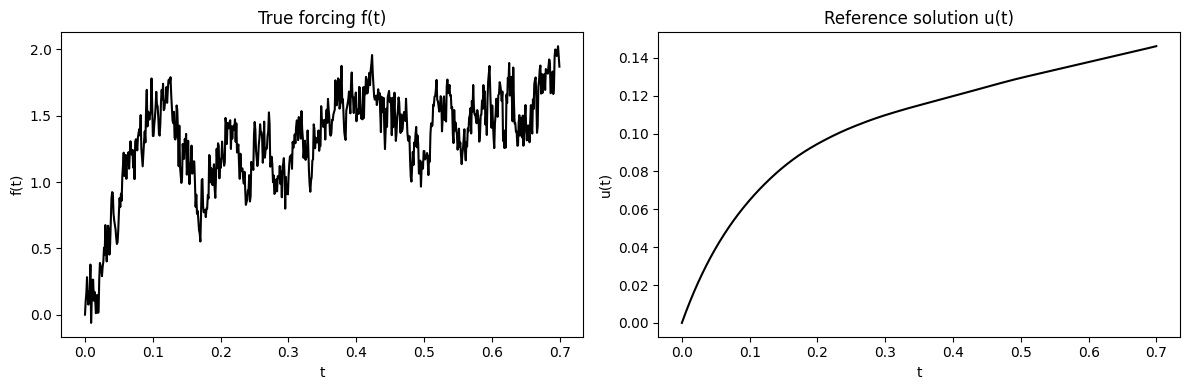

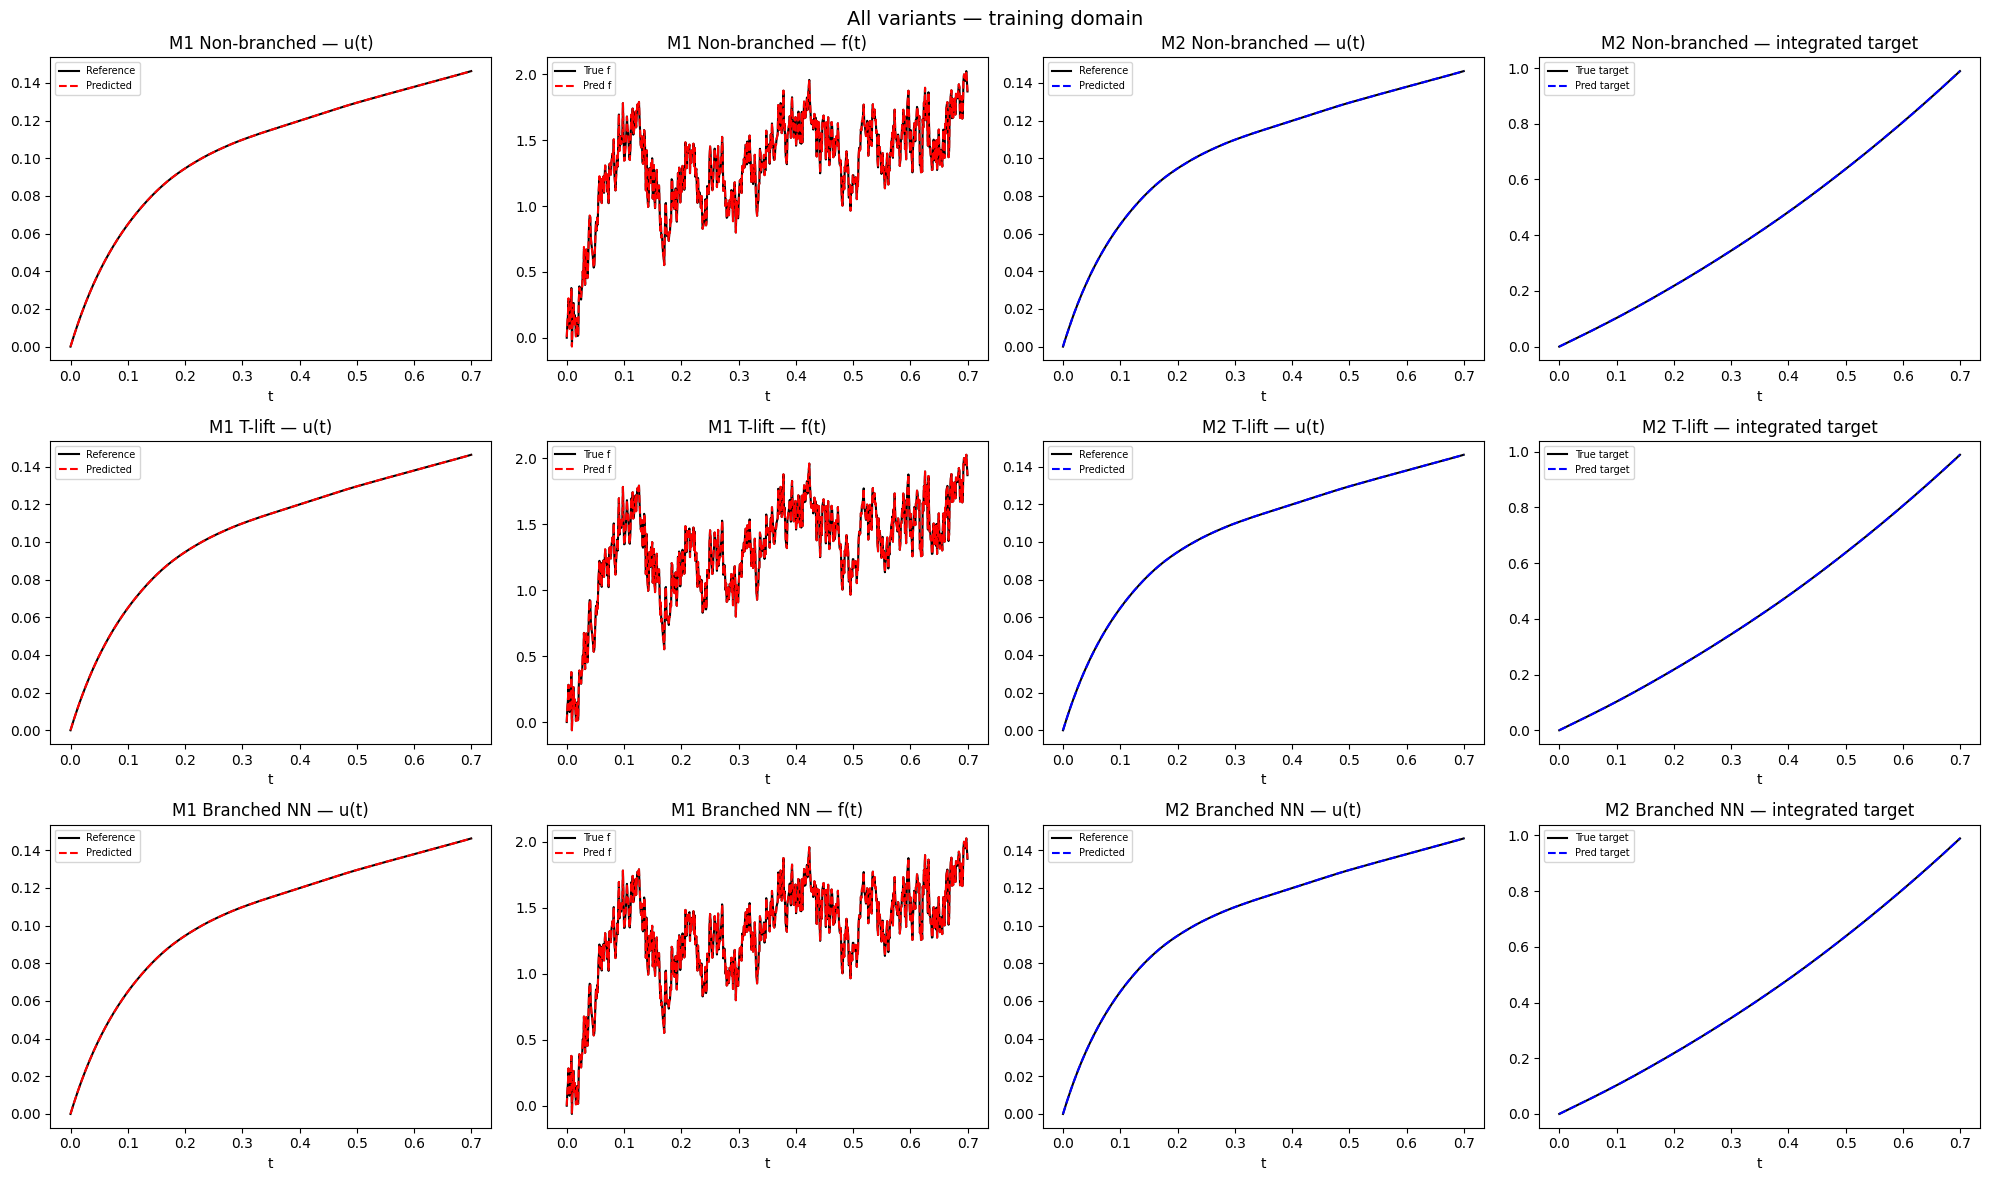

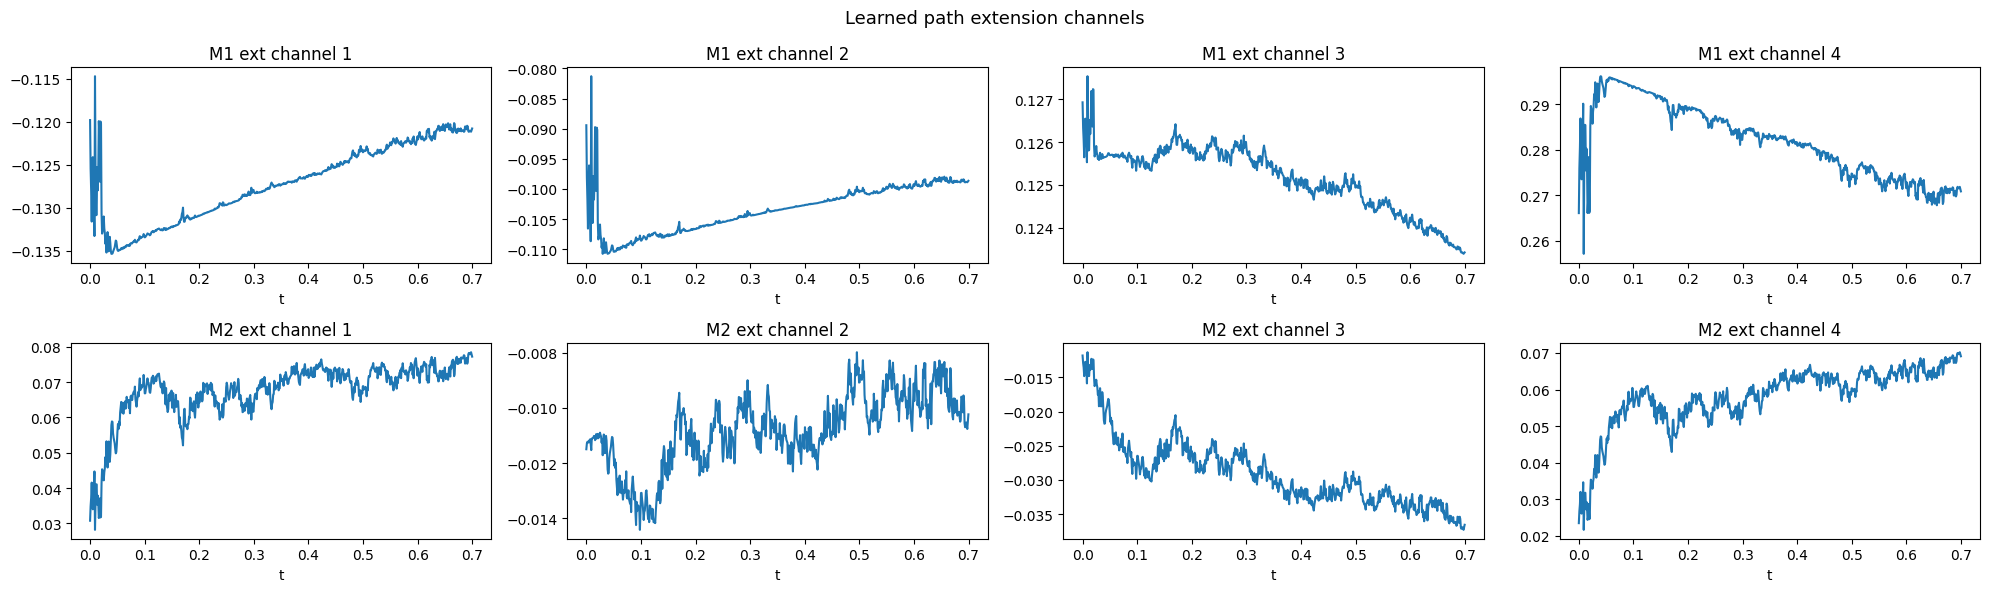

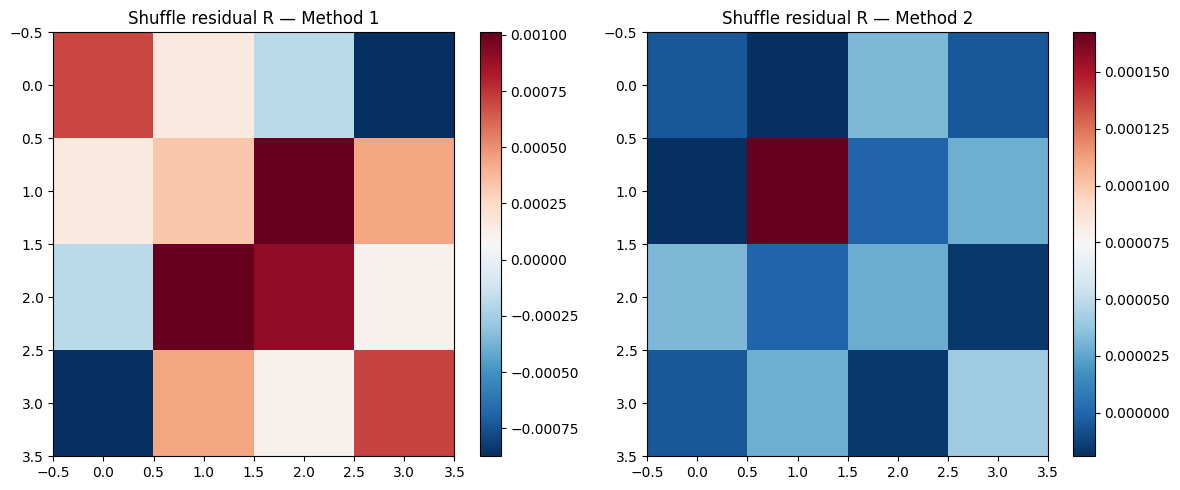

In [6]:
plot_reference_forcing_and_solution(
    x=x_train, f_true=forcing_train, u_ref=u_ref_train
)

# ── Unified comparison plot: all variants × both methods ──
rhs_nb_m2  = rhs_method2(forcing_train, x_train, ya, ypa, k1, k2)
rhs_tl_m2  = rhs_nb_m2   # same true target for all method 2 variants
rhs_sig_m2 = rhs_nb_m2

plot_all_variants_comparison(
    x=x_train, f_true=forcing_train, u_ref=u_ref_train,
    f_pred_nb_m1=f_pred_nb_m1,   u_nb_m1=u_nb_m1,
    f_pred_tl_m1=f_pred_tl_m1,   u_tl_m1=u_tl_m1,
    f_pred_sig_m1=f_pred_sig_m1, u_sig_m1=u_sig_m1,
    f_pred_nb_m2=f_pred_nb_m2,   u_nb_m2=u_nb_m2,
    f_pred_tl_m2=f_pred_tl_m2,   u_tl_m2=u_tl_m2,
    f_pred_sig_m2=f_pred_sig_m2, u_sig_m2=u_sig_m2,
    f_target_nb_m2=rhs_nb_m2,
    f_target_tl_m2=rhs_tl_m2,
    f_target_sig_m2=rhs_sig_m2,
)

# ── Unified extensions plot ──
plot_all_extensions(
    x=x_train, f_true=forcing_train,
    path_ext_m1=path_ext_m1,
    path_ext_m2=path_ext_m2,
)

# ── Unified shuffle residual matrix plot ──
plot_all_shuffle_matrices(
    x=x_train, f_true=forcing_train,
    path_ext_m1=path_ext_m1,
    path_ext_m2=path_ext_m2,
)

# Testing with retrain

In [7]:
print("\nRunning TESTING routines on train/test split...\n")

forcing_test = forcing[N_train:]

# ── Test: Non-branched, method 1 ──
print("testing non-branched, method 1")
u_test_nb_m1, f_test_pred_nb_m1 = test_nonbranched_method1(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=10,
)

# ── Test: t-lift, method 1 ──
print("testing t-lift, method 1")
u_test_tl_m1, f_test_pred_tl_m1 = test_branched_tlift_method1(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    holder_value=HOLDER_VALUE,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=10,
)

# ── Test: learned branched NN, method 1 ──
print("testing branched NN, method 1")
u_test_sig_m1, f_test_pred_sig_m1 = test_branched_NN_method1(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    pathextension=path_ext_m1,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=10,
)

# ── Test: Non-branched, method 2 ──
print("testing non-branched, method 2")
u_test_nb_m2, f_test_pred_nb_m2 = test_nonbranched_method2(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=10,
)

# ── Test: t-lift, method 2 ──
print("testing t-lift, method 2")
u_test_tl_m2, f_test_pred_tl_m2 = test_branched_tlift_method2(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    holder_value=HOLDER_VALUE,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=10,
)

# ── Test: learned branched NN, method 2 ──
print("testing branched NN, method 2")
u_test_sig_m2, f_test_pred_sig_m2 = test_branched_NN_method2(
    x_train=x_train,
    x_test=x_test,
    f_train=forcing_train,
    f_test=forcing_test,
    k1=k1,
    k2=k2,
    k3=k3,
    ua=ya,
    upa=ypa,
    depth=SIG_DEPTH,
    rbf_sigma=rbf_sigma,
    pathextension=path_ext_m2,
    kernel_type=KERNEL_TYPE,
    norm_scheme=NORM_SCHEME,
    norm_kwargs=NORM_KWARGS,
    retrain_every=10,
)


Running TESTING routines on train/test split...

testing non-branched, method 1


RuntimeError: expected scalar type Float but found Double

In [ ]:
# === Full-grid reference solution (needed for full-path and test-only comparisons) ===
print("\nsolving ivp reference (full grid)")
x_ref_full, u_ref_full = solve_linear_ivp(
    x_grid=x,
    forcing_torch=forcing,
    a=float(x[0]), b=float(x[-1]),
    ya=ya, ypa=ypa,
    k1=k1, k2=k2, k3=k3
)

# === Build full-path predictions by concatenating training + testing outputs ===
u_nb_m1_full       = torch.cat([u_nb_m1,  u_test_nb_m1[N_train:]],  dim=0)
f_pred_nb_m1_full  = torch.cat([f_pred_nb_m1,  f_test_pred_nb_m1[N_train:]],  dim=0)

u_tl_m1_full       = torch.cat([u_tl_m1,  u_test_tl_m1[N_train:]],  dim=0)
f_pred_tl_m1_full  = torch.cat([f_pred_tl_m1,  f_test_pred_tl_m1[N_train:]],  dim=0)

u_sig_m1_full      = torch.cat([u_sig_m1,  u_test_sig_m1[N_train:]],  dim=0)
f_pred_sig_m1_full = torch.cat([f_pred_sig_m1, f_test_pred_sig_m1[N_train:]], dim=0)

u_nb_m2_full       = torch.cat([u_nb_m2,  u_test_nb_m2[N_train:]],  dim=0)
f_pred_nb_m2_full  = torch.cat([f_pred_nb_m2,  f_test_pred_nb_m2[N_train:]],  dim=0)

u_tl_m2_full       = torch.cat([u_tl_m2,  u_test_tl_m2[N_train:]],  dim=0)
f_pred_tl_m2_full  = torch.cat([f_pred_tl_m2,  f_test_pred_tl_m2[N_train:]],  dim=0)

u_sig_m2_full      = torch.cat([u_sig_m2,  u_test_sig_m2[N_train:]],  dim=0)
f_pred_sig_m2_full = torch.cat([f_pred_sig_m2, f_test_pred_sig_m2[N_train:]], dim=0)

# === True Method 2 targets ===
rhs_true_m2_full = rhs_method2(f=forcing,       x=x,      ua=ya, upa=ypa, k1=k1, k2=k2)
rhs_true_m2_test = rhs_method2(f=forcing_test,  x=x_test, ua=ya, upa=ypa, k1=k1, k2=k2)

# === Compare and Print Results (FULL train+test) ===
print("\nComparing ALL variants on FULL path (train+test): "
      "non-branched, t-lift, branched | method 1 vs method 2")

print("\n--- Method 1 (FULL) ---")
print_variant_errors("Non-branched", u_nb_m1_full,  f_pred_nb_m1_full,  u_ref_full, forcing, x)
print_variant_errors("t-lift      ", u_tl_m1_full,  f_pred_tl_m1_full,  u_ref_full, forcing, x)
print_variant_errors("Branched    ", u_sig_m1_full, f_pred_sig_m1_full, u_ref_full, forcing, x)

print("\n--- Method 2 (FULL) ---")
print_variant_errors("Non-branched", u_nb_m2_full,  f_pred_nb_m2_full,  u_ref_full, rhs_true_m2_full, x)
print_variant_errors("t-lift      ", u_tl_m2_full,  f_pred_tl_m2_full,  u_ref_full, rhs_true_m2_full, x)
print_variant_errors("Branched    ", u_sig_m2_full, f_pred_sig_m2_full, u_ref_full, rhs_true_m2_full, x)

# ── Method 1: % improvement vs non-branched baseline (FULL) ──
nb_m1_full  = get_errors(u_nb_m1_full,  f_pred_nb_m1_full,  u_ref_full, forcing)
tl_m1_full  = get_errors(u_tl_m1_full,  f_pred_tl_m1_full,  u_ref_full, forcing)
sig_m1_full = get_errors(u_sig_m1_full, f_pred_sig_m1_full, u_ref_full, forcing)

print("\n--- Method 1 (FULL): % improvement vs Non-branched (positive = better) ---")
print("  [Non-branched]  (baseline)")
print_pct_improvement("t-lift      ", tl_m1_full,  nb_m1_full)
print_pct_improvement("Branched    ", sig_m1_full, nb_m1_full)

# ── Method 2: % improvement vs non-branched baseline (FULL) ──
nb_m2_full  = get_errors(u_nb_m2_full,  f_pred_nb_m2_full,  u_ref_full, rhs_true_m2_full)
tl_m2_full  = get_errors(u_tl_m2_full,  f_pred_tl_m2_full,  u_ref_full, rhs_true_m2_full)
sig_m2_full = get_errors(u_sig_m2_full, f_pred_sig_m2_full, u_ref_full, rhs_true_m2_full)

print("\n--- Method 2 (FULL): % improvement vs Non-branched (positive = better) ---")
print("  [Non-branched]  (baseline)")
print_pct_improvement("t-lift      ", tl_m2_full,  nb_m2_full)
print_pct_improvement("Branched    ", sig_m2_full, nb_m2_full)

# ── Method 1 vs Method 2: % solution improvement per variant (FULL) ──
print("\n--- Method 1 vs Method 2 (FULL): % solution improvement "
      "(positive = Method 1 better) ---")

for label, e_m1, e_m2 in [
    ("Non-branched", nb_m1_full,  nb_m2_full),
    ("t-lift      ", tl_m1_full,  tl_m2_full),
    ("Branched    ", sig_m1_full, sig_m2_full),
]:
    def pct(m1_val, m2_val): return 100.0 * (m2_val - m1_val) / (abs(m2_val) + 1e-12)
    print(f"  [{label}]"
          f"  MSE(u)={pct(e_m1['mse_u'], e_m2['mse_u']):+.1f}%"
          f"  Rel(u)={pct(e_m1['rel_u'], e_m2['rel_u']):+.1f}%")

# === Compare and Print Results (TEST portion only) ===
u_ref_test   = u_ref_full[N_train:]
forcing_test = forcing[N_train:]

u_nb_m1_test       = u_nb_m1_full[N_train:]
f_pred_nb_m1_test  = f_pred_nb_m1_full[N_train:]
u_tl_m1_test       = u_tl_m1_full[N_train:]
f_pred_tl_m1_test  = f_pred_tl_m1_full[N_train:]
u_sig_m1_test      = u_sig_m1_full[N_train:]
f_pred_sig_m1_test = f_pred_sig_m1_full[N_train:]

u_nb_m2_test       = u_nb_m2_full[N_train:]
f_pred_nb_m2_test  = f_pred_nb_m2_full[N_train:]
u_tl_m2_test       = u_tl_m2_full[N_train:]
f_pred_tl_m2_test  = f_pred_tl_m2_full[N_train:]
u_sig_m2_test      = u_sig_m2_full[N_train:]
f_pred_sig_m2_test = f_pred_sig_m2_full[N_train:]

print("\nComparing ALL variants on TEST ONLY: non-branched, t-lift, branched | method 1 vs method 2")

print("\n--- Method 1 (TEST ONLY) ---")
print_variant_errors("Non-branched", u_nb_m1_test,  f_pred_nb_m1_test,  u_ref_test, forcing_test, x_test)
print_variant_errors("t-lift      ", u_tl_m1_test,  f_pred_tl_m1_test,  u_ref_test, forcing_test, x_test)
print_variant_errors("Branched    ", u_sig_m1_test, f_pred_sig_m1_test, u_ref_test, forcing_test, x_test)

print("\n--- Method 2 (TEST ONLY) ---")
print_variant_errors("Non-branched", u_nb_m2_test,  f_pred_nb_m2_test,  u_ref_test, rhs_true_m2_test, x_test)
print_variant_errors("t-lift      ", u_tl_m2_test,  f_pred_tl_m2_test,  u_ref_test, rhs_true_m2_test, x_test)
print_variant_errors("Branched    ", u_sig_m2_test, f_pred_sig_m2_test, u_ref_test, rhs_true_m2_test, x_test)

# ── Method 1: % improvement vs non-branched baseline (TEST) ──
nb_m1_test  = get_errors(u_nb_m1_test,  f_pred_nb_m1_test,  u_ref_test, forcing_test)
tl_m1_test  = get_errors(u_tl_m1_test,  f_pred_tl_m1_test,  u_ref_test, forcing_test)
sig_m1_test = get_errors(u_sig_m1_test, f_pred_sig_m1_test, u_ref_test, forcing_test)

print("\n--- Method 1 (TEST ONLY): % improvement vs Non-branched (positive = better) ---")
print("  [Non-branched]  (baseline)")
print_pct_improvement("t-lift      ", tl_m1_test,  nb_m1_test)
print_pct_improvement("Branched    ", sig_m1_test, nb_m1_test)

# ── Method 2: % improvement vs non-branched baseline (TEST) ──
nb_m2_test  = get_errors(u_nb_m2_test,  f_pred_nb_m2_test,  u_ref_test, rhs_true_m2_test)
tl_m2_test  = get_errors(u_tl_m2_test,  f_pred_tl_m2_test,  u_ref_test, rhs_true_m2_test)
sig_m2_test = get_errors(u_sig_m2_test, f_pred_sig_m2_test, u_ref_test, rhs_true_m2_test)

print("\n--- Method 2 (TEST ONLY): % improvement vs Non-branched (positive = better) ---")
print("  [Non-branched]  (baseline)")
print_pct_improvement("t-lift      ", tl_m2_test,  nb_m2_test)
print_pct_improvement("Branched    ", sig_m2_test, nb_m2_test)

# ── Method 1 vs Method 2: % solution improvement per variant (TEST) ──
print("\n--- Method 1 vs Method 2 (TEST ONLY): % solution improvement "
      "(positive = Method 1 better) ---")

for label, e_m1, e_m2 in [
    ("Non-branched", nb_m1_test,  nb_m2_test),
    ("t-lift      ", tl_m1_test,  tl_m2_test),
    ("Branched    ", sig_m1_test, sig_m2_test),
]:
    def pct(m1_val, m2_val): return 100.0 * (m2_val - m1_val) / (abs(m2_val) + 1e-12)
    print(f"  [{label}]"
          f"  MSE(u)={pct(e_m1['mse_u'], e_m2['mse_u']):+.1f}%"
          f"  Rel(u)={pct(e_m1['rel_u'], e_m2['rel_u']):+.1f}%")

In [ ]:
# === Plots: FULL train+test and TEST only ===

# 1) Full path: all variants, Method 1 & 2
plot_all_variants_full_train_test(
    x_full=x,
    f_true_full=forcing,
    u_ref_full=u_ref_full,
    u_nb_m1_full=u_nb_m1_full,
    f_pred_nb_m1_full=f_pred_nb_m1_full,
    u_tl_m1_full=u_tl_m1_full,
    f_pred_tl_m1_full=f_pred_tl_m1_full,
    u_sig_m1_full=u_sig_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    u_nb_m2_full=u_nb_m2_full,
    f_pred_nb_m2_full=f_pred_nb_m2_full,
    u_tl_m2_full=u_tl_m2_full,
    f_pred_tl_m2_full=f_pred_tl_m2_full,
    u_sig_m2_full=u_sig_m2_full,
    f_pred_sig_m2_full=f_pred_sig_m2_full,
    f_target_nb_m2_full=rhs_true_m2_full,
    f_target_tl_m2_full=rhs_true_m2_full,
    f_target_sig_m2_full=rhs_true_m2_full,
)

# 2) Test portion only: all variants, Method 1 & 2
plot_all_variants_test_only(
    x_test=x_test,
    u_ref_full=u_ref_full,
    f_true_full=forcing,
    u_nb_m1_full=u_nb_m1_full,
    f_pred_nb_m1_full=f_pred_nb_m1_full,
    u_tl_m1_full=u_tl_m1_full,
    f_pred_tl_m1_full=f_pred_tl_m1_full,
    u_sig_m1_full=u_sig_m1_full,
    f_pred_sig_m1_full=f_pred_sig_m1_full,
    u_nb_m2_full=u_nb_m2_full,
    f_pred_nb_m2_full=f_pred_nb_m2_full,
    u_tl_m2_full=u_tl_m2_full,
    f_pred_tl_m2_full=f_pred_tl_m2_full,
    u_sig_m2_full=u_sig_m2_full,
    f_pred_sig_m2_full=f_pred_sig_m2_full,
    N_train=N_train,
    f_target_nb_m2_full=rhs_true_m2_full,
    f_target_tl_m2_full=rhs_true_m2_full,
    f_target_sig_m2_full=rhs_true_m2_full,
)

In [ ]:
# ── SELECTION ────────────────────────────────────────────────────────────────
METRIC = "RElMSE"   # <--- change to "MSE" or "RelMSE"


# ── map already-computed get_errors() results into lookup dicts ──────────────
train_errs = {
    ("Method 1", "Non-branched"): {"mseu": nb_m1_full["mse_u"],  "relu": nb_m1_full["rel_u"],  "msef": nb_m1_full["mse_f"],  "relf": nb_m1_full["rel_f"]},
    ("Method 1", "T-lift"):       {"mseu": tl_m1_full["mse_u"],  "relu": tl_m1_full["rel_u"],  "msef": tl_m1_full["mse_f"],  "relf": tl_m1_full["rel_f"]},
    ("Method 1", "Branched"):     {"mseu": sig_m1_full["mse_u"], "relu": sig_m1_full["rel_u"], "msef": sig_m1_full["mse_f"], "relf": sig_m1_full["rel_f"]},
    ("Method 2", "Non-branched"): {"mseu": nb_m2_full["mse_u"],  "relu": nb_m2_full["rel_u"],  "msef": nb_m2_full["mse_f"],  "relf": nb_m2_full["rel_f"]},
    ("Method 2", "T-lift"):       {"mseu": tl_m2_full["mse_u"],  "relu": tl_m2_full["rel_u"],  "msef": tl_m2_full["mse_f"],  "relf": tl_m2_full["rel_f"]},
    ("Method 2", "Branched"):     {"mseu": sig_m2_full["mse_u"], "relu": sig_m2_full["rel_u"], "msef": sig_m2_full["mse_f"], "relf": sig_m2_full["rel_f"]},
}

test_errs = {
    ("Method 1", "Non-branched"): {"mseu": nb_m1_test["mse_u"],  "relu": nb_m1_test["rel_u"],  "msef": nb_m1_test["mse_f"],  "relf": nb_m1_test["rel_f"]},
    ("Method 1", "T-lift"):       {"mseu": tl_m1_test["mse_u"],  "relu": tl_m1_test["rel_u"],  "msef": tl_m1_test["mse_f"],  "relf": tl_m1_test["rel_f"]},
    ("Method 1", "Branched"):     {"mseu": sig_m1_test["mse_u"], "relu": sig_m1_test["rel_u"], "msef": sig_m1_test["mse_f"], "relf": sig_m1_test["rel_f"]},
    ("Method 2", "Non-branched"): {"mseu": nb_m2_test["mse_u"],  "relu": nb_m2_test["rel_u"],  "msef": nb_m2_test["mse_f"],  "relf": nb_m2_test["rel_f"]},
    ("Method 2", "T-lift"):       {"mseu": tl_m2_test["mse_u"],  "relu": tl_m2_test["rel_u"],  "msef": tl_m2_test["mse_f"],  "relf": tl_m2_test["rel_f"]},
    ("Method 2", "Branched"):     {"mseu": sig_m2_test["mse_u"], "relu": sig_m2_test["rel_u"], "msef": sig_m2_test["mse_f"], "relf": sig_m2_test["rel_f"]},
}


# ── metric selection ─────────────────────────────────────────────────────────
if METRIC == "MSE":
    u_col, f_col, label = "mseu", "msef", "MSE"
else:
    u_col, f_col, label = "relu", "relf", "Rel-MSE"   # was "Rel-L2"


methods  = ["Method 1", "Method 2"]
variants = ["Non-branched", "T-lift", "Branched"]

def val(errs_dict, method, variant, col):
    e = errs_dict.get((method, variant), {})
    v = e.get(col, None)
    return float(v) if v is not None else float("nan")

import pandas as pd
from IPython.display import display, HTML

BASE_STYLES = [
    {"selector": "caption",
     "props": [("font-size", "14px"), ("font-weight", "bold"),
               ("text-align", "left"), ("padding-bottom", "6px")]},
    {"selector": "th",
     "props": [("font-size", "12px"), ("text-align", "center"),
               ("padding", "6px 12px"), ("border-bottom", "2px solid #000"),
               ("background-color", "white"), ("color", "black")]},
    {"selector": "td",
     "props": [("text-align", "right"), ("font-family", "monospace"),
               ("font-size", "12px"), ("padding", "5px 12px"),
               ("background-color", "white"), ("color", "black")]},
    {"selector": "tr",
     "props": [("background-color", "white"), ("color", "black")]},
    {"selector": "",
     "props": [("border", "1px solid #ccc"), ("background-color", "white")]},
]

def show(df, caption):
    display(HTML(f"<br><b style='font-size:13px; color:black'>{caption}</b>"))
    display(
        df.style
          .format("{:.3e}")
          .set_table_styles(BASE_STYLES)
          .set_properties(**{"background-color": "white", "color": "black"})
    )

# ── Table 1: Method Comparison (u only) ──────────────────────────────────────
t1_data = {}
for method in methods:
    for variant in variants:
        t1_data[(method, variant)] = {
            "Train": val(train_errs, method, variant, u_col),
            "Test":  val(test_errs,  method, variant, u_col),
        }

t1 = pd.DataFrame(
    {(method, variant): t1_data[(method, variant)]
     for method in methods for variant in variants}
).T
t1.index = pd.MultiIndex.from_tuples(t1.index, names=["Method", "Variant"])
show(t1, f"Method Comparison — {label}(u)")

# ── Table 2: Method 1 (u and f, Test and Train) ───────────────────────────────
t2_rows = {}
for variant in variants:
    t2_rows[variant] = {
        ("Testing",  "Forcing"):  val(test_errs,  "Method 1", variant, f_col),
        ("Testing",  "Solution"): val(test_errs,  "Method 1", variant, u_col),
        ("Training", "Forcing"):  val(train_errs, "Method 1", variant, f_col),
        ("Training", "Solution"): val(train_errs, "Method 1", variant, u_col),
    }

t2 = pd.DataFrame(t2_rows).T
t2.index.name = "Variant"
t2.columns = pd.MultiIndex.from_tuples(t2.columns, names=["Split", "Target"])
show(t2, f"Method 1 — {label}")

# ── Table 3: Method 2 (u and f, Test and Train) ───────────────────────────────
t3_rows = {}
for variant in variants:
    t3_rows[variant] = {
        ("Testing",  "Int. Forcing"): val(test_errs,  "Method 2", variant, f_col),
        ("Testing",  "Solution"):     val(test_errs,  "Method 2", variant, u_col),
        ("Training", "Int. Forcing"): val(train_errs, "Method 2", variant, f_col),
        ("Training", "Solution"):     val(train_errs, "Method 2", variant, u_col),
    }

t3 = pd.DataFrame(t3_rows).T
t3.index.name = "Variant"
t3.columns = pd.MultiIndex.from_tuples(t3.columns, names=["Split", "Target"])
show(t3, f"Method 2 — {label}")

In [ ]:



# ── call ─────────────────────────────────────────────────────────────────────
plot_m1_forcing_calibration_sidebyside(
    x         = x_test,
    ftrue     = forcing[N_train:],
    fpred_nb  = f_pred_nb_m1_full[N_train:],
    fpred_sig = f_pred_sig_m1_full[N_train:],
)

In [ ]:
# ── call ─────────────────────────────────────────────────────────────────────
plot_m1_branched_full_sidebyside(
    x_full             = x,
    forcing_full       = forcing,
    u_ref_full         = u_ref_full,
    f_pred_sig_m1_full = f_pred_sig_m1_full,
    u_sig_m1_full      = u_sig_m1_full,
    N_train            = N_train,
)